In [13]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


RBD = (22520, 23186)
region_start = (22882, 23063)

In [14]:
# get first JN1 detection date
prevalences = pd.read_csv('../data/PointLoma_sewage_seqs.csv')
first_jn1_date = prevalences[prevalences['JN.1.X'] > 0]['Date'].min()

# load covar data
covar = pd.read_csv('../data/covar_clinical_detections.tsv', sep='\t')

# filter by date, including 3 months after first JN.1 detection
covar = covar[(covar['collection_date'] >= first_jn1_date) & (covar['collection_date'] < (pd.to_datetime(first_jn1_date) + pd.DateOffset(months=6)).strftime('%Y-%m-%d'))]

# filter by RBD mutations
covar = covar[(covar['coverage_start'] >= RBD[0]) & (covar['coverage_end'] <= RBD[1])]

# unique mutations in this period
covar = covar[['nt_mutations', 'collection_date']].drop_duplicates().reset_index(drop=True)
covar.to_csv('rbd_unique_mutations.tsv', sep='\t', index=False)

covar['collection_date'] = pd.to_datetime(covar['collection_date'])
covar = covar.sort_values('collection_date')

covar = covar.groupby('collection_date').count().reset_index()

# bin by week
covar = covar.set_index('collection_date').resample('W').sum().reset_index()

   collection_date  nt_mutations
0       2023-11-19             1
1       2023-11-26             1
2       2023-12-03             4
3       2023-12-10             5
4       2023-12-17            12
5       2023-12-24             3
6       2023-12-31             9
7       2024-01-07             0
8       2024-01-14             2
9       2024-01-21             1
10      2024-01-28             4
11      2024-02-04             3
12      2024-02-11             0
13      2024-02-18             0
14      2024-02-25             2
15      2024-03-03            32
16      2024-03-10            48
17      2024-03-17           123
18      2024-03-24            16
19      2024-03-31            81
20      2024-04-07            51
21      2024-04-14            57
22      2024-04-21            58
23      2024-04-28            21
24      2024-05-05            21
25      2024-05-12            16
26      2024-05-19            31


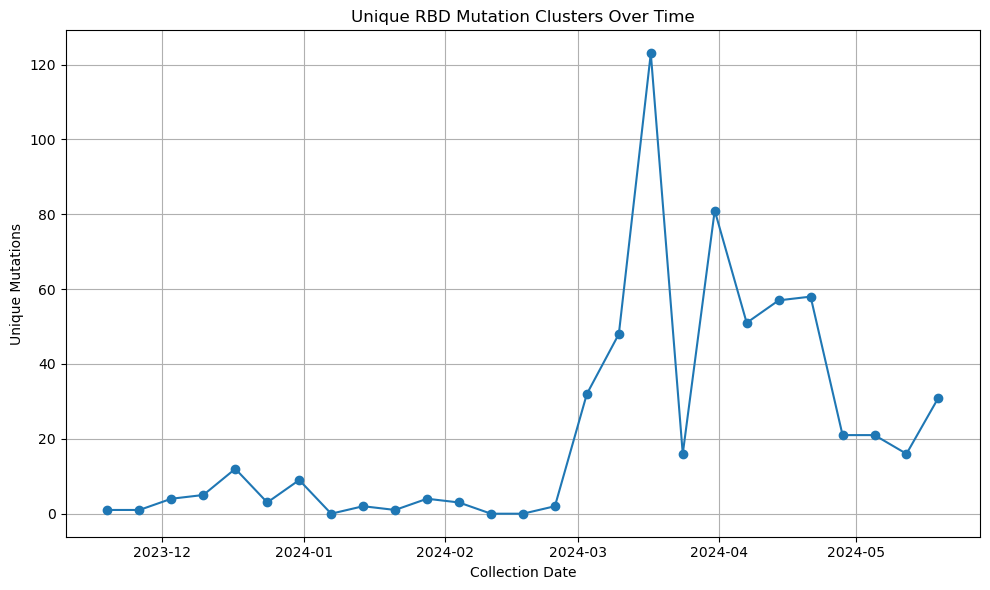

In [ ]:
# plot number of unique nt mutations over time


print(covar)
plt.figure(figsize=(10,6))
plt.plot(covar['collection_date'], covar['nt_mutations'], marker='o')
plt.title('Unique RBD Mutation Clusters Over Time')
plt.xlabel('Collection Date')
plt.ylabel('Unique Mutations')
plt.grid()
plt.tight_layout()
plt.savefig('variant_introduction/rbd_unique_mutations_over_time.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

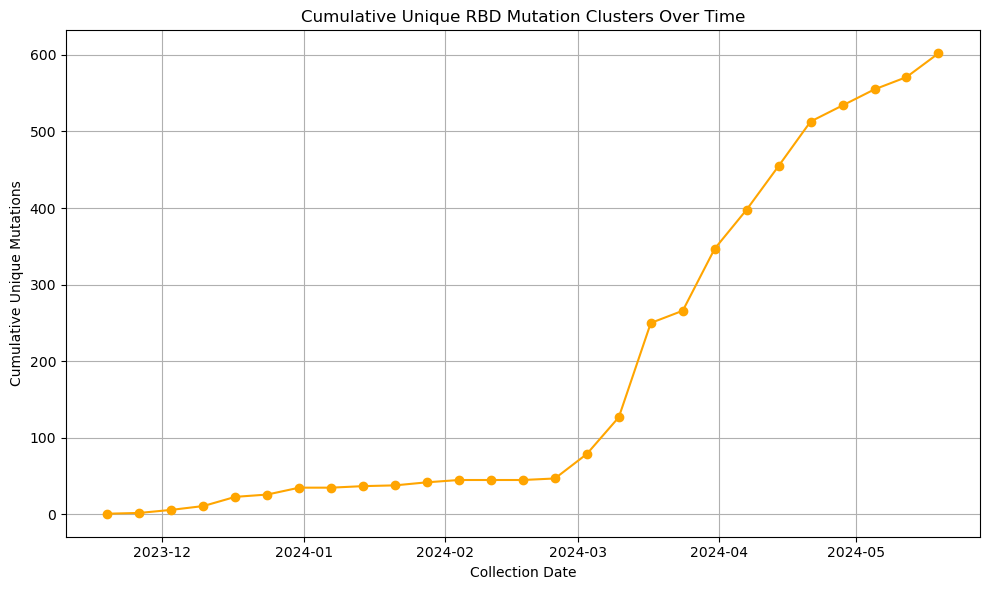

In [16]:
# plot cumulative unique mutations over time
covar['cumulative_mutations'] = covar['nt_mutations'].cumsum()
plt.figure(figsize=(10,6))
plt.plot(covar['collection_date'], covar['cumulative_mutations'], marker='o', color='orange')
plt.title('Cumulative Unique RBD Mutation Clusters Over Time')
plt.xlabel('Collection Date')
plt.ylabel('Cumulative Unique Mutations')
plt.grid()
plt.tight_layout()
plt.savefig('variant_introduction/cumulative_rbd_mutations.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()